In [1]:
# Imports and environment setup
import torch
import numpy as np
import pandas as pd
from transformers import AutoTokenizer, AutoModelForMaskedLM
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Device configuration - use MPS on Apple Silicon
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Using device: {device}")

# Paths
DATA_DIR = Path('../data')
print(f"Data directory: {DATA_DIR.resolve()}")

/Users/rnorel/.pyenv/versions/3.11.14/envs/esm-variant-agent/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: mps
Data directory: /Users/rnorel/Documents/Learning/esm-variant-agent/data


# Notebook 01 — ESM2 Embeddings and Cosine Distance Analysis

## Objective
Explore whether cosine distance between ESM2 embeddings of wildtype and mutant 
protein sequences can predict mutation fitness effects.

**Protein:** BLAT_ECOLX — *E. coli* beta-lactamase, the enzyme responsible for 
antibiotic resistance to penicillins and cephalosporins.

**Data:** ProteinGym DMS benchmark — 4,996 single amino acid substitutions with 
experimental fitness scores from deep mutational scanning (Stiffler et al., 2015).

**Model:** `facebook/esm2_t6_8M_UR50D` — smallest ESM2 variant (8M parameters), 
trained on 250M protein sequences via masked language modeling.

In [2]:
# Load ESM2 model and tokenizer
# Using esm2_t6_8M_UR50D - smallest ESM2 model, fast on M4
MODEL_NAME = "facebook/esm2_t6_8M_UR50D"

print(f"Loading tokenizer: {MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print(f"Loading model: {MODEL_NAME}")
model = AutoModelForMaskedLM.from_pretrained(MODEL_NAME)
model = model.to(device)
model.eval()

print(f"\nModel loaded successfully")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Device: {next(model.parameters()).device}")

Loading tokenizer: facebook/esm2_t6_8M_UR50D
Loading model: facebook/esm2_t6_8M_UR50D


Loading weights: 100%|████████████████████████████████████████████████████████████████████████████████████████████| 107/107 [00:00<00:00, 27430.51it/s]


Model loaded successfully
Parameters: 7,512,474
Device: mps:0


In [6]:
# Load ProteinGym dataset - BLAT_ECOLX (E. coli beta-lactamase)
# Classic antibiotic resistance protein, 1480 single amino acid substitutions
# Experimental fitness scores from deep mutational scanning

CSV_PATH = DATA_DIR / "BLAT_ECOLX_Stiffler_2015.csv"

df = pd.read_csv(CSV_PATH)
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nDMS score range: {df['DMS_score'].min():.3f} to {df['DMS_score'].max():.3f}")
print(f"DMS score bin counts:\n{df['DMS_score_bin'].value_counts()}")
df.head(3)

Shape: (4996, 4)
Columns: ['mutant', 'mutated_sequence', 'DMS_score', 'DMS_score_bin']

DMS score range: -3.743 to 0.356
DMS score bin counts:
DMS_score_bin
1    2498
0    2498
Name: count, dtype: int64


,mutant,mutated_sequence,DMS_score,DMS_score_bin
0,H24C,MSIQHFRVALIPFFAAFCLPVFACPETLVKVKDAEDQLGARVGYIE...,-0.418260,1
1,H24Y,MSIQHFRVALIPFFAAFCLPVFAYPETLVKVKDAEDQLGARVGYIE...,-0.885025,1
2,H24W,MSIQHFRVALIPFFAAFCLPVFAWPETLVKVKDAEDQLGARVGYIE...,-1.347586,0


In [7]:
# Dataset exploration and wildtype sequence extraction
print("=== Dataset Overview ===")
print(f"Total mutations: {len(df)}")
print(f"DMS score range: {df['DMS_score'].min():.3f} to {df['DMS_score'].max():.3f}")
print(f"DMS score mean: {df['DMS_score'].mean():.3f}")
print(f"\nBin counts (0=deleterious, 1=neutral/beneficial):")
print(df['DMS_score_bin'].value_counts())

# Extract wildtype sequence from the first mutant
# mutant format: "H24C" = His->Cys at position 24
# We can reconstruct wildtype by reverting the mutation
first_mutant = df.iloc[0]
mut_notation = first_mutant['mutant']  # e.g. "H24C"
wt_aa = mut_notation[0]               # original amino acid
position = int(mut_notation[1:-1])    # position (1-indexed)
mut_aa = mut_notation[-1]             # mutated amino acid

mutated_seq = first_mutant['mutated_sequence']

# Reconstruct wildtype: revert mutation at position
wt_sequence = list(mutated_seq)
wt_sequence[position - 1] = wt_aa
wt_sequence = ''.join(wt_sequence)

print(f"\n=== Wildtype Sequence ===")
print(f"Length: {len(wt_sequence)} amino acids")
print(f"First 50 aa: {wt_sequence[:50]}")
print(f"\nVerification - position {position}:")
print(f"  Wildtype: {wt_sequence[position-1]} (expected {wt_aa})")
print(f"  Mutant:   {mutated_seq[position-1]} (expected {mut_aa})")

=== Dataset Overview ===
Total mutations: 4996
DMS score range: -3.743 to 0.356
DMS score mean: -1.256

Bin counts (0=deleterious, 1=neutral/beneficial):
DMS_score_bin
1    2498
0    2498
Name: count, dtype: int64

=== Wildtype Sequence ===
Length: 286 amino acids
First 50 aa: MSIQHFRVALIPFFAAFCLPVFAHPETLVKVKDAEDQLGARVGYIELDLN

Verification - position 24:
  Wildtype: H (expected H)
  Mutant:   C (expected C)


In [8]:
# Compute ESM2 embeddings for wildtype + subset of mutants
# Using 100 mutations (50 deleterious + 50 neutral) for speed

# Balanced subset
df_del = df[df['DMS_score_bin'] == 0].sample(50, random_state=42)
df_neu = df[df['DMS_score_bin'] == 1].sample(50, random_state=42)
df_subset = pd.concat([df_del, df_neu]).reset_index(drop=True)

print(f"Subset: {len(df_subset)} mutations ({len(df_del)} deleterious, {len(df_neu)} neutral)")

# All sequences to embed: wildtype + 100 mutants
sequences = [wt_sequence] + df_subset['mutated_sequence'].tolist()
labels = ['wildtype'] + df_subset['mutant'].tolist()

print(f"Total sequences to embed: {len(sequences)}")
print(f"Sequence length: {len(sequences[0])} aa")

def get_embedding(sequence: str) -> np.ndarray:
    """Extract mean-pooled embedding from ESM2 for a single sequence."""
    inputs = tokenizer(sequence, return_tensors='pt', truncation=True, max_length=1024)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True)
    
    # Use last hidden state, mean pool over sequence length (exclude special tokens)
    hidden = outputs.hidden_states[-1]  # (1, seq_len+2, hidden_dim)
    embedding = hidden[0, 1:-1, :].mean(dim=0).cpu().numpy()  # mean pool, remove <cls> <eos>
    return embedding

# Compute embeddings
print("\nComputing embeddings...")
embeddings = []
for i, seq in enumerate(sequences):
    emb = get_embedding(seq)
    embeddings.append(emb)
    if i % 20 == 0:
        print(f"  {i}/{len(sequences)}")

embeddings = np.array(embeddings)
print(f"\nEmbeddings shape: {embeddings.shape}")
print(f"Wildtype embedding shape: {embeddings[0].shape}")

Subset: 100 mutations (50 deleterious, 50 neutral)
Total sequences to embed: 101
Sequence length: 286 aa

Computing embeddings...
  0/101
  20/101
  40/101
  60/101
  80/101
  100/101

Embeddings shape: (101, 320)
Wildtype embedding shape: (320,)


=== Embedding Distance Analysis ===

Cosine distance (wildtype vs mutants):
  Deleterious (bin=0): 0.000295
  Neutral (bin=1):     0.000180

Spearman correlation (cosine_dist vs DMS_score): rho=-0.070, p=4.919e-01


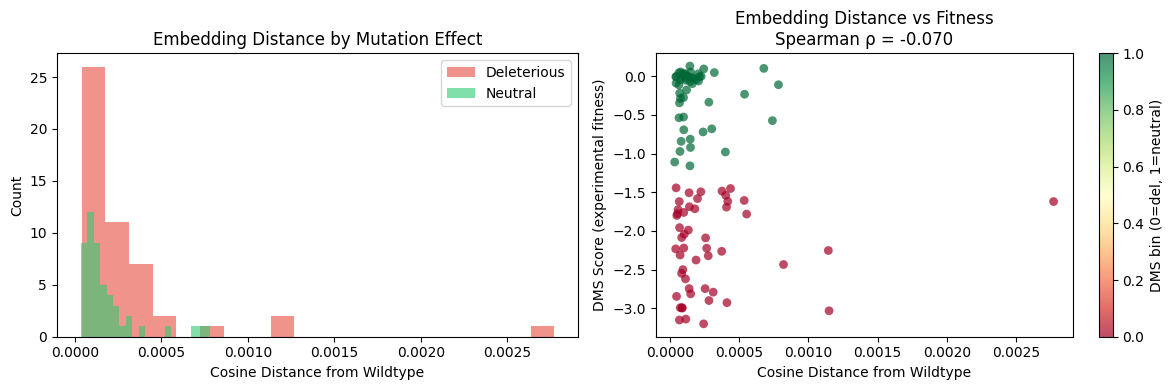

Figure saved to reports/fig01_embedding_distances.png


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import cosine
from scipy.stats import spearmanr

# Compute cosine distance from each mutant to wildtype
wt_emb = embeddings[0]
mutant_embs = embeddings[1:]

cosine_distances = np.array([cosine(wt_emb, m) for m in mutant_embs])
df_subset['cosine_dist'] = cosine_distances

print("=== Embedding Distance Analysis ===")
print(f"\nCosine distance (wildtype vs mutants):")
print(f"  Deleterious (bin=0): {df_subset[df_subset['DMS_score_bin']==0]['cosine_dist'].mean():.6f}")
print(f"  Neutral (bin=1):     {df_subset[df_subset['DMS_score_bin']==1]['cosine_dist'].mean():.6f}")

# Spearman correlation with DMS score
rho, pval = spearmanr(df_subset['cosine_dist'], df_subset['DMS_score'])
print(f"\nSpearman correlation (cosine_dist vs DMS_score): rho={rho:.3f}, p={pval:.3e}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: cosine distance by bin
ax = axes[0]
colors = {0: '#e74c3c', 1: '#2ecc71'}
for bin_val, label in [(0, 'Deleterious'), (1, 'Neutral')]:
    vals = df_subset[df_subset['DMS_score_bin']==bin_val]['cosine_dist']
    ax.hist(vals, alpha=0.6, label=label, color=colors[bin_val], bins=20)
ax.set_xlabel('Cosine Distance from Wildtype')
ax.set_ylabel('Count')
ax.set_title('Embedding Distance by Mutation Effect')
ax.legend()

# Right: scatter cosine_dist vs DMS_score
ax = axes[1]
scatter = ax.scatter(df_subset['cosine_dist'], df_subset['DMS_score'],
                     c=df_subset['DMS_score_bin'], cmap='RdYlGn',
                     alpha=0.7, edgecolors='none', s=40)
ax.set_xlabel('Cosine Distance from Wildtype')
ax.set_ylabel('DMS Score (experimental fitness)')
ax.set_title(f'Embedding Distance vs Fitness\nSpearman ρ = {rho:.3f}')
plt.colorbar(scatter, ax=ax, label='DMS bin (0=del, 1=neutral)')

plt.tight_layout()
plt.savefig('../reports/fig01_embedding_distances.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved to reports/fig01_embedding_distances.png")

In [10]:
# Save embeddings and metadata for notebook 02
np.save(DATA_DIR / 'embeddings_wt.npy', wt_emb)
np.save(DATA_DIR / 'embeddings_mutants.npy', mutant_embs)
df_subset.to_csv(DATA_DIR / 'df_subset_with_distances.csv', index=False)

print("Saved:")
print(f"  embeddings_wt.npy       shape: {wt_emb.shape}")
print(f"  embeddings_mutants.npy  shape: {mutant_embs.shape}")
print(f"  df_subset_with_distances.csv  rows: {len(df_subset)}")
print("\nNotebook 01 complete.")
print("Finding: cosine distance (Spearman rho=-0.070) is a weak signal.")
print("Next: log-likelihood ratio scoring in notebook 02.")

Saved:
  embeddings_wt.npy       shape: (320,)
  embeddings_mutants.npy  shape: (100, 320)
  df_subset_with_distances.csv  rows: 100

Notebook 01 complete.
Finding: cosine distance (Spearman rho=-0.070) is a weak signal.
Next: log-likelihood ratio scoring in notebook 02.
